# 05 · Agent Watch (rule-based, case-level evaluation)

With ~9 rogue agents, a supervised model would learn 9 examples. Agent Watch instead scores each agent-day
against **peers in the same area on the same day** (volume vs peer median, night share, share paid to
wallets under 7 days old, pass-through share, share already reported to 16268) and evaluates per **episode**.
A second signal tests whether fraud victims cluster on one agent's register (Poisson test vs footfall).

In [1]:
# --- setup: find the repo root (works locally, in Colab and on Kaggle) -------------------------
import os, sys, shutil, subprocess
from pathlib import Path

REPO_URL = ""          # optional: your GitHub repo URL, cloned if the code is not found
ROOT = None
for cand in [Path.cwd(), Path.cwd().parent, *Path("/kaggle/input").glob("*")] if Path("/kaggle/input").exists() else [Path.cwd(), Path.cwd().parent]:
    if (cand / "src" / "pipeline.py").exists():
        ROOT = cand
        break
if ROOT is None and REPO_URL:
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, "prohori"], check=True)
    ROOT = Path("prohori").resolve()
assert ROOT is not None, "Put this notebook next to the repo (or add the repo as a Kaggle dataset / set REPO_URL)"
if str(ROOT).startswith("/kaggle/input"):          # Kaggle inputs are read-only: work on a copy
    dst = Path("/kaggle/working/prohori")
    shutil.copytree(ROOT, dst, dirs_exist_ok=True)
    ROOT = dst
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
print("repo root:", ROOT)

repo root: H:\Tacos Projects\Hackathon\Asking for a Friend


In [2]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40, "display.width", 200)
from src.common.config import load_config, resolve
from src.models import plots
plots.style()
cfg = load_config()                 # config.yaml (seed 42, full scale)
REPORTS = resolve(cfg, "reports_dir")

,agent_day_precision,agent_day_recall,episodes,episodes_flagged,false_alarm_agent_days_per_day
test,0.542,0.565,9.0,6.0,1.10
train,0.500,0.600,18.0,15.0,0.68
val,0.625,0.625,9.0,8.0,0.90


register compromise: {'harvested_agents': 4, 'harvested_flagged': 3, 'other_agents_flagged': 1}
SC-06: {'agent': 'A00044', 'max_score': 85.8, 'flagged': True, 'flagged_days': [54, 55, 56], 'max_volume_vs_peer_median': 10.4}


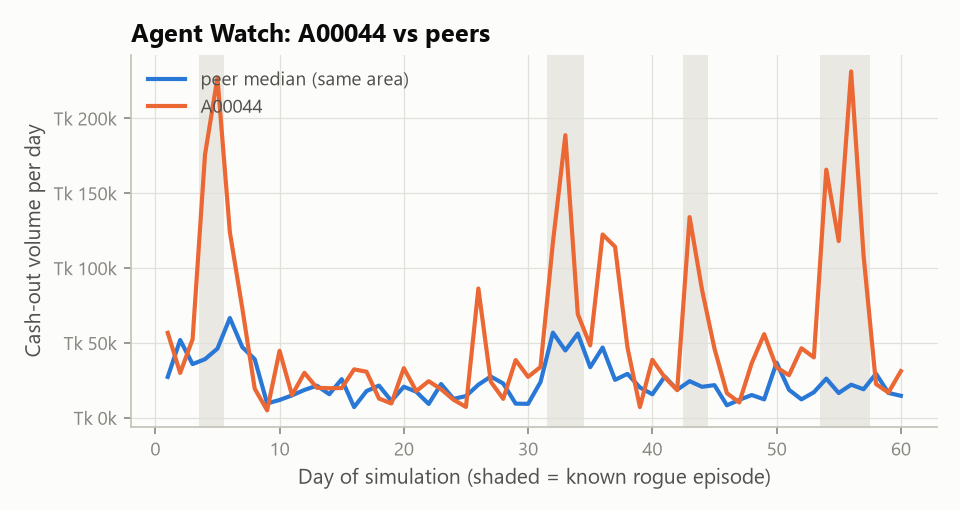

In [3]:
RERUN = False
if RERUN or not (REPORTS / "agent_watch.json").exists():
    from src.agents.agent_watch import run
    run(cfg)
aw = json.loads((REPORTS / "agent_watch.json").read_text(encoding="utf-8"))
display(pd.DataFrame(aw["by_split"]).T)
print("register compromise:", aw["register_compromise"])
print("SC-06:", aw["sc06"])
display(Image(filename=str(REPORTS / "figures" / "agent_watch_sc06.png")))

In [4]:
ad = pd.read_parquet(resolve(cfg, "features_dir") / "agent_scores.parquet")
ad.groupby("is_episode")[["cashouts", "volume", "volume_ratio", "night_share", "young_share", "pass_share", "reported_share", "score"]].median().round(2)

,cashouts,volume,volume_ratio,night_share,young_share,pass_share,reported_share,score
is_episode,,,,,,,,
False,3.0,10300.0,1.00,0.0,0.0,0.00,0.00,8.1
True,9.0,80550.0,6.33,0.1,0.0,0.33,0.08,83.1


In [5]:
pd.DataFrame(aw["top_agents_last_day"])

,agent_id,area_id,score,cashouts,volume,night_share,young_share
0,A00190,SYL-06,87.9,7.0,19500.0,0.0,0.0
1,A00293,MYM-05,82.7,3.0,17700.0,0.0,0.0
2,A00248,RNG-04,76.8,5.0,22400.0,0.0,0.0
3,A00253,RNG-05,73.2,5.0,26900.0,0.0,0.0
4,A00152,KHU-06,72.2,3.0,19000.0,0.0,0.0
5,A00247,RNG-04,69.5,5.0,30900.0,0.0,0.0
6,A00297,MYM-06,69.4,3.0,21400.0,0.0,0.0
7,A00149,KHU-05,68.4,2.0,8400.0,0.0,0.5
8,A00246,RNG-03,67.7,4.0,3000.0,0.0,0.0
9,A00282,MYM-03,65.9,4.0,25000.0,0.0,0.0
